# R-GCN Knowledge Graph Training

**Phase 3 of the NeuroVLM GNN experiment.**

Trains a Relational Graph Convolutional Network (R-GCN) on the unified neuroscience KG for link prediction, then extracts entity and relation embeddings.

| Step | What happens |
|---|---|
| 7 | Load unified KG · assign contiguous entity/relation integers · 85/7.5/7.5 stratified split · filtered negative sampling |
| 8 | Build R-GCN (2 × RGCNConv, basis decomposition) + DistMult decoder |
| 9 | Train with BCE loss · early stopping on val MRR · Hits@1/3/10 monitoring |
| 10 | Extract entity + relation embeddings · save with ID maps · nearest-neighbour spot-check |

## Setup

In [1]:
# ── Install PyTorch Geometric if not already present ──────────────────────────
# pip install torch_geometric
#
# torch_scatter / torch_sparse are optional extras; RGCNConv works without them
# on most platforms.  If you hit an ImportError for scatter/sparse, run:
#   pip install torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-<version>+<cuda>.html
# where <version> = torch.__version__ (e.g. 2.3.0) and <cuda> = cu121 / cpu.

In [2]:
import sys
from pathlib import Path

repo_root = Path("..").resolve()
src_dir = repo_root / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

print("Repo root:", repo_root)
print("src dir  :", src_dir)

import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

print("torch    :", torch.__version__)
print("device   :", "cuda" if torch.cuda.is_available() else
      ("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu"))

Repo root: /Users/borng/code/lab_work/neurovlm
src dir  : /Users/borng/code/lab_work/neurovlm/src
torch    : 2.10.0
device   : mps


---
## Step 7 — Load KG and Prepare Training Data

In [3]:
from neurovlm.gnn.kg_data import load_kg, KGSplits

DATA = repo_root / "experiments" / "data" / "unified_kg"

kg = load_kg(
    nodes_path=DATA / "unified_kg_nodes.parquet",
    edges_path=DATA / "unified_kg_edges.parquet",
)

KG loaded: 33,784 entities, 6 relation types, 329,566 triples.
  Relation types: ['associated_with_disorder', 'co_activates_with', 'co_occurs_with', 'expressed_in', 'implicated_in', 'narrower_term_of']


In [4]:
# ── Inspect the KG ────────────────────────────────────────────────────────────
print(f"Entities  : {kg.num_entities:,}")
print(f"Relations : {kg.num_relations}")
print(f"Triples   : {len(kg.triples):,}")
print()
print("Relation type → integer index:")
for rel, idx in sorted(kg.relation_to_idx.items(), key=lambda x: x[1]):
    count = (kg.triples[:, 1] == idx).sum().item()
    print(f"  {idx}  {rel:<35}  {count:>7,} triples")

Entities  : 33,784
Relations : 6
Triples   : 329,566

Relation type → integer index:
  0  associated_with_disorder               2,107 triples
  1  co_activates_with                        931 triples
  2  co_occurs_with                       281,629 triples
  3  expressed_in                             577 triples
  4  implicated_in                          1,803 triples
  5  narrower_term_of                      42,519 triples


In [5]:
# ── Stratified 85 / 7.5 / 7.5 split ─────────────────────────────────────────
splits = KGSplits.from_kg(kg, train_frac=0.85, val_frac=0.075, seed=42)

print(f"train edge_index shape : {splits.train_edge_index.shape}")
print(f"train edge_type shape  : {splits.train_edge_type.shape}")

Split: train=280,136  val=24,715  test=24,715
train edge_index shape : torch.Size([2, 280136])
train edge_type shape  : torch.Size([280136])


In [6]:
# ── Verify stratification — every relation type must appear in all splits ─────
for split_name, triples in [("train", splits.train_triples),
                             ("val",   splits.val_triples),
                             ("test",  splits.test_triples)]:
    rels_present = sorted(triples[:, 1].unique().tolist())
    print(f"{split_name:5s}  {len(triples):>7,} triples  relations present: {rels_present}")

train  280,136 triples  relations present: [0, 1, 2, 3, 4, 5]
val     24,715 triples  relations present: [0, 1, 2, 3, 4, 5]
test    24,715 triples  relations present: [0, 1, 2, 3, 4, 5]


In [7]:
# ── Peek at a training batch with negatives ───────────────────────────────────
from torch.utils.data import DataLoader
from neurovlm.gnn.kg_data import kg_collate_fn

train_ds = splits.train_dataset(neg_ratio=10)
loader_preview = DataLoader(train_ds, batch_size=4, shuffle=False, collate_fn=kg_collate_fn)
batch = next(iter(loader_preview))

print("positives shape:", batch["positives"].shape)   # (4, 3)
print("negatives shape:", batch["negatives"].shape)   # (40, 3)
print()
print("Example positive triple (s, r, o):")
s, r, o = batch["positives"][0].tolist()
print(f"  {kg.idx_to_entity[s]}  --[{kg.idx_to_relation[r]}]-->  {kg.idx_to_entity[o]}")

positives shape: torch.Size([4, 3])
negatives shape: torch.Size([40, 3])

Example positive triple (s, r, o):
  D002544  --[associated_with_disorder]-->  D009434


---
## Step 8 — Model Setup

In [8]:
from neurovlm.gnn.rgcn import RGCNLinkPredictor

model = RGCNLinkPredictor(
    num_entities=kg.num_entities,   # 33,784
    num_relations=kg.num_relations, # 6
    emb_dim=256,
    num_bases=4,
    num_layers=2,
    dropout=0.1,
)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params:,}")

RGCNLinkPredictor(
  (entity_emb): Embedding(33784, 256)
  (convs): ModuleList(
    (0-1): 2 x RGCNConv(256, 256, num_relations=6)
  )
  (relation_emb): Embedding(6, 256)
)

Total parameters: 9,306,160


In [9]:
# ── Sanity-check a forward pass before training ───────────────────────────────
with torch.no_grad():
    emb = model.encode(splits.train_edge_index, splits.train_edge_type)
    print("entity_emb shape :", emb.shape)   # (33784, 256)

    # Score one batch of positives
    pos = splits.train_triples[:8]
    scores = model.score(emb, pos[:, 0], pos[:, 1], pos[:, 2])
    print("pos scores shape :", scores.shape)
    print("pos scores       :", scores.round(decimals=4))

entity_emb shape : torch.Size([33784, 256])
pos scores shape : torch.Size([8])
pos scores       : tensor([0.0004, 0.0002, 0.0000, 0.0003, 0.0004, 0.0004, 0.0002, 0.0003])


---
## Step 9 — Training

In [10]:
from neurovlm.gnn.kg_train import RGCNTrainer

CHECKPOINT_DIR = repo_root / "checkpoints" / "rgcn"

trainer = RGCNTrainer(
    model=model,
    splits=splits,
    lr=1e-3,
    weight_decay=1e-4,
    n_epochs=500,
    batch_size=1024,
    neg_ratio=10,
    eval_batch_size=512,
    val_interval=10,   # evaluate val MRR every 10 epochs
    patience=30,       # early-stop after 30 epochs without MRR improvement
    lr_patience=10,
    lr_factor=0.5,
    device="auto",
    checkpoint_dir=CHECKPOINT_DIR,
    verbose=True,
)

In [11]:
trainer.fit()

R-GCN training: 500 epochs, batch=1024, neg_ratio=10, device=mps
  entities=33,784  relations=6  train_triples=280,136
Epoch   10/500 | loss=0.0564 | MRR=0.0497 | H@1=0.0133 | H@3=0.0414 | H@10=0.1130 | lr=1.00e-03 | 550.3s
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/rgcn/best_rgcn.pt
Epoch   20/500 | loss=0.0441 | MRR=0.0547 | H@1=0.0150 | H@3=0.0464 | H@10=0.1262 | lr=1.00e-03 | 553.6s
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/rgcn/best_rgcn.pt
Epoch   25/500 | loss=0.0409 | lr=1.00e-03
Epoch   30/500 | loss=0.0386 | MRR=0.0619 | H@1=0.0208 | H@3=0.0539 | H@10=0.1363 | lr=1.00e-03 | 550.9s
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/rgcn/best_rgcn.pt
Epoch   40/500 | loss=0.0354 | MRR=0.0685 | H@1=0.0237 | H@3=0.0629 | H@10=0.1503 | lr=1.00e-03 | 562.3s
  → checkpoint saved to /Users/borng/code/lab_work/neurovlm/checkpoints/rgcn/best_rgcn.pt
Epoch   50/500 | loss=0.0332 | MRR=0.0693 | H@1=0.0261 | H

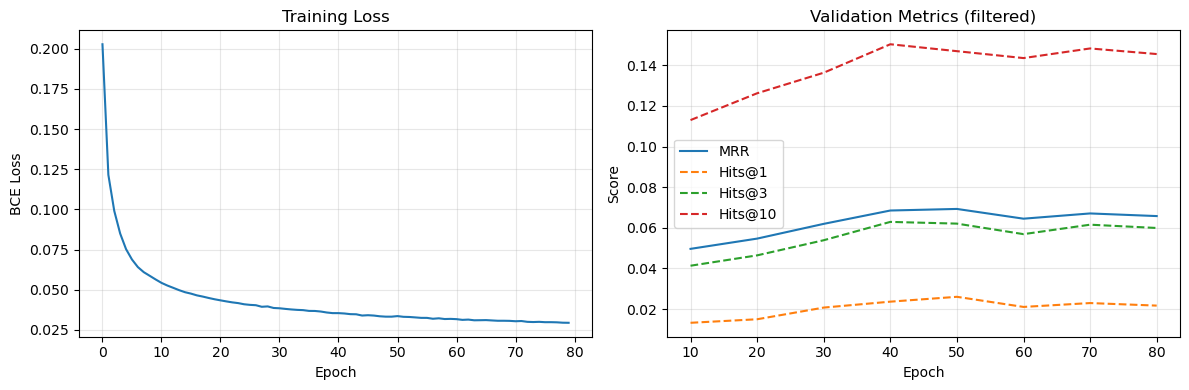

Best val MRR: 0.0693


In [12]:
# ── Plot training loss and validation MRR ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(trainer.history["train_loss"])
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

val_epochs = list(range(10, 10 * len(trainer.history["val_mrr"]) + 1, 10))
ax2.plot(val_epochs, trainer.history["val_mrr"],   label="MRR")
ax2.plot(val_epochs, trainer.history["val_hits@1"], label="Hits@1", linestyle="--")
ax2.plot(val_epochs, trainer.history["val_hits@3"], label="Hits@3", linestyle="--")
ax2.plot(val_epochs, trainer.history["val_hits@10"],label="Hits@10",linestyle="--")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Validation Metrics (filtered)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(DATA / "rgcn_training_curves.png", dpi=150)
plt.show()
print(f"Best val MRR: {trainer._best_mrr:.4f}")

---
## Test-set Evaluation

In [13]:
test_metrics = trainer.evaluate_test()

print("\nTest results (filtered ranking):")
for k, v in test_metrics.items():
    print(f"  {k:<10} {v:.4f}")

Test | MRR=0.0699 | H@1=0.0255 | H@3=0.0632 | H@10=0.1496

Test results (filtered ranking):
  mrr        0.0699
  hits@1     0.0255
  hits@3     0.0632
  hits@10    0.1496


---
## Step 10 — Extract and Save Embeddings

In [14]:
EMB_PATH = DATA / "entity_embeddings.pt"
trainer.save_embeddings(EMB_PATH)

Embeddings saved to /Users/borng/code/lab_work/neurovlm/experiments/data/unified_kg/entity_embeddings.pt
  entity_embeddings : torch.Size([33784, 256])
  relation_embeddings: torch.Size([6, 256])


In [21]:
# ── Reload and inspect saved embeddings ──────────────────────────────────────
payload = torch.load(EMB_PATH, weights_only=False)

entity_emb   = payload["entity_embeddings"]    # (33784, 256)
relation_emb = payload["relation_embeddings"]  # (6, 256)

# Build canonical_id → human-readable name lookup from nodes parquet
nodes_df = pd.read_parquet(DATA / "unified_kg_nodes.parquet")
id_to_name = nodes_df.set_index("canonical_id")["name"].to_dict()

print("entity_embeddings  :", entity_emb.shape)
print("relation_embeddings:", relation_emb.shape)
print()
print("Relation embedding norms:")
for idx, name in payload["idx_to_relation"].items():
    norm = relation_emb[idx].norm().item()
    print(f"  {idx}  {name:<35}  norm={norm:.4f}")

entity_embeddings  : torch.Size([33784, 256])
relation_embeddings: torch.Size([6, 256])

Relation embedding norms:
  0  associated_with_disorder             norm=3.5408
  1  co_activates_with                    norm=2.9786
  2  co_occurs_with                       norm=2.2299
  3  expressed_in                         norm=3.7718
  4  implicated_in                        norm=3.2966
  5  narrower_term_of                     norm=2.4755


In [22]:
# ── Nearest-neighbour spot-check ──────────────────────────────────────────────
# Hippocampus (D006624) should be near: entorhinal cortex, spatial memory,
# Alzheimer disease, memory consolidation, etc.
# If it's near retina or cardiac muscle, entity normalisation likely failed.

def show_neighbours(query: str, k: int = 10):
    neighbours = trainer.nearest_neighbours(query, k=k, entity_emb=entity_emb)
    query_name = id_to_name.get(query, query)
    print(f"\nNearest neighbours for '{query_name}' ({query}):")
    for sim, eid in neighbours:
        name = id_to_name.get(eid, eid)
        print(f"  {sim:.4f}  {name:<45}  ({eid})")

show_neighbours("D006624")  # Hippocampus


Nearest neighbours for 'Hippocampus' (D006624):
  0.8905  Neurons                                        (D009474)
  0.8454  Neural Pathways                                (D009434)
  0.8324  Cerebral Cortex                                (D002540)
  0.8178  Nerve Net                                      (D009415)
  0.8165  Prefrontal Cortex                              (D017397)
  0.7993  Amygdala                                       (D000679)
  0.7948  Thalamus                                       (D013788)
  0.7907  Temporal Lobe                                  (D013702)
  0.7703  Limbic System                                  (D008032)
  0.7699  Frontal Lobe                                   (D005625)


In [23]:
show_neighbours("D000544")  # Alzheimer Disease


Nearest neighbours for 'Alzheimer Disease' (D000544):
  0.7501  Parkinson Disease                              (D010300)
  0.6754  Cognitive Dysfunction                          (D060825)
  0.6722  Major Depressive Disorder                      (D003865)
  0.6656  Dementia                                       (D003704)
  0.6644  Atrophy                                        (D001284)
  0.6544  Psychotic Disorders                            (D011618)
  0.6524  Amyloid beta-Peptides                          (D016229)
  0.6511  Neurodegenerative Diseases                     (D019636)
  0.6455  Depression                                     (D003863)
  0.6299  tau Proteins                                   (D016875)


In [25]:
show_neighbours("D000679")  # Amygdala


Nearest neighbours for 'Amygdala' (D000679):
  0.8298  Limbic System                                  (D008032)
  0.7993  Hippocampus                                    (D006624)
  0.7951  Prefrontal Cortex                              (D017397)
  0.7755  Frontal Lobe                                   (D005625)
  0.7646  Gyrus Cinguli                                  (D006179)
  0.7446  Emotions                                       (D004644)
  0.7422  Parahippocampal Gyrus                          (D020534)
  0.7394  Neural Pathways                                (D009434)
  0.7378  Temporal Lobe                                  (D013702)
  0.7355  Parietal Lobe                                  (D010296)


In [ ]:
# ── UMAP of entity embeddings (optional — requires umap-learn) ────────────────
# pip install umap-learn
try:
    import umap
    import numpy as np

    nodes_df = pd.read_parquet(DATA / "unified_kg_nodes.parquet")
    type_map = nodes_df.set_index("canonical_id")["node_type"].to_dict()

    emb_np = F.normalize(entity_emb, dim=-1).numpy()

    reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42, n_neighbors=15)
    coords = reducer.fit_transform(emb_np)

    node_types = [type_map.get(kg.idx_to_entity[i], "other") for i in range(kg.num_entities)]
    unique_types = sorted(set(node_types))
    color_map = {t: plt.cm.tab10(i / len(unique_types)) for i, t in enumerate(unique_types)}
    colors = [color_map[t] for t in node_types]

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=1, alpha=0.4, linewidths=0)

    handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[t],
                          markersize=8, label=t) for t in unique_types]
    ax.legend(handles=handles, title="node_type", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.set_title("UMAP of R-GCN entity embeddings (cosine)")
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(DATA / "rgcn_umap.png", dpi=150, bbox_inches="tight")
    plt.show()

except ImportError:
    print("umap-learn not installed — skipping UMAP visualisation.\npip install umap-learn")

---
## Output Files

| file | description |
|---|---|
| `experiments/data/unified_kg/entity_embeddings.pt` | Entity + relation embeddings with ID maps |
| `experiments/data/unified_kg/rgcn_training_curves.png` | Loss + MRR training curves |
| `experiments/data/unified_kg/rgcn_umap.png` | UMAP of entity embedding space (if umap-learn is installed) |
| `checkpoints/rgcn/best_rgcn.pt` | Best model checkpoint |